# 1. Análise Descritiva
Nesta seção, realizamos a leitura dos dados, exibimos as características das colunas, tratamos valores ausentes (se houverem) e plotamos visualizações fundamentais para entender o perfil dos estudantes.

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Carregar os dados da pasta instances
df = pd.read_csv('instances/estudantes.csv')

# Exibir informações gerais do DataFrame
print('--- Informações do DataFrame ---')
df.info()

# Tratar valores nulos (Se existirem, substituímos pela mediana para manter a integridade dos tipos numéricos)
if df.isnull().sum().any():
    print('\nTratando valores nulos...')
    df.fillna(df.median(), inplace=True)
else:
    print('\nNão há valores nulos na base de dados.')

--- Informações do DataFrame ---
<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   frequencia            6 non-null      float64
 1   media_notas           6 non-null      float64
 2   renda_familiar        6 non-null      int64  
 3   idade                 6 non-null      int64  
 4   historico_repetencia  6 non-null      int64  
 5   risco_evasao          6 non-null      int64  
dtypes: float64(2), int64(4)
memory usage: 420.0 bytes

Não há valores nulos na base de dados.


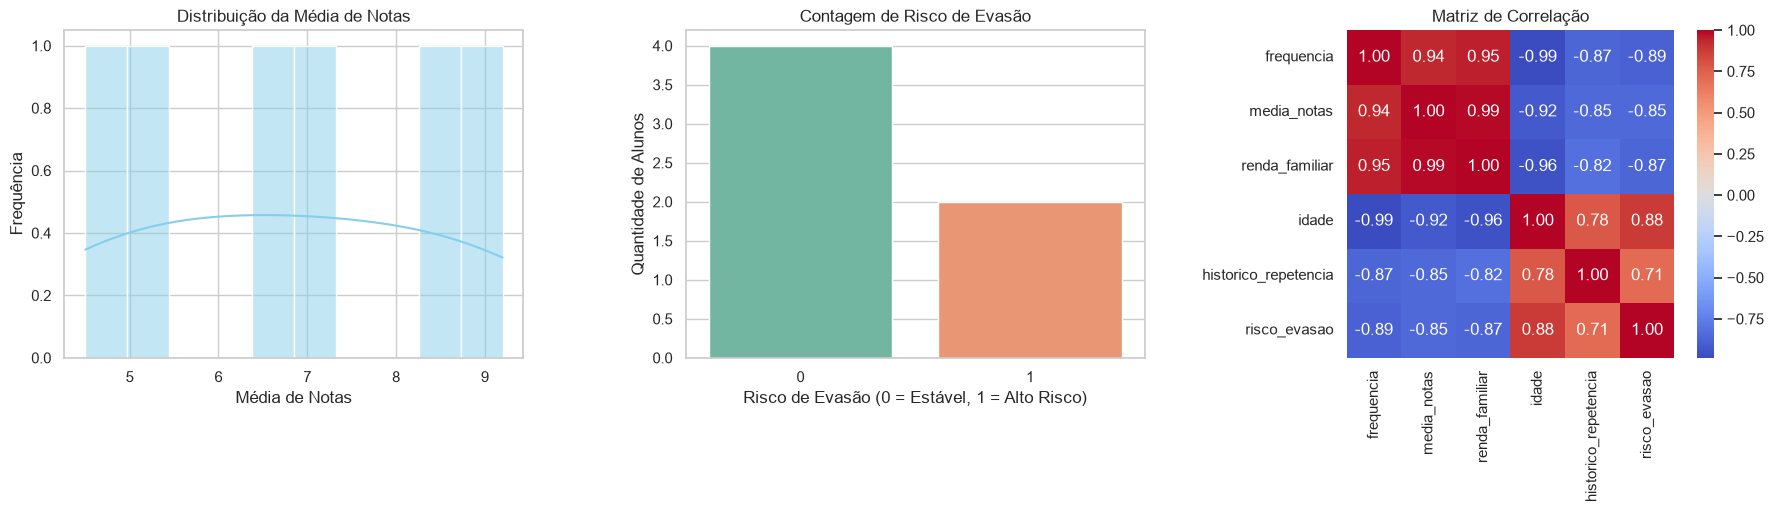

In [10]:
# Configurar estilo das visualizações
sns.set_theme(style='whitegrid')
plt.figure(figsize=(18, 5))

# 1. Histograma das notas
plt.subplot(1, 3, 1)
sns.histplot(df['media_notas'], kde=True, color='skyblue', bins=10)
plt.title('Distribuição da Média de Notas')
plt.xlabel('Média de Notas')
plt.ylabel('Frequência')

# 2. Gráfico de Barras do risco de evasão
plt.subplot(1, 3, 2)
sns.countplot(data=df, x='risco_evasao', palette='Set2', hue='risco_evasao', legend=False)
plt.title('Contagem de Risco de Evasão')
plt.xlabel('Risco de Evasão (0 = Estável, 1 = Alto Risco)')
plt.ylabel('Quantidade de Alunos')

# 3. Matriz de Correlação
plt.subplot(1, 3, 3)
correlacao = df.corr()
sns.heatmap(correlacao, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Matriz de Correlação')

plt.tight_layout()
plt.show()

# 2. Experimentos (Regra dos 30 Testes)
Aqui aplicamos 3 diferentes modelos preditivos (DecisionTree, RandomForest e Regressão Logística). O experimento consiste em executá-los 30 vezes, em 30 diferentes divisões dos dados de treino e teste, para avaliar sua performance em diferentes cenários sem viés.

In [11]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore') # Ocultar avisos pontuais de métricas em amostras muito pequenas

# Aumentar o volume de dados duplicando o dataframe provisório
df = pd.concat([df]*10, ignore_index=True)

# Separar Variáveis Explicativas e Variável Alvo
X = df.drop('risco_evasao', axis=1)
y = df['risco_evasao']

# Instanciar um dicionário para acomodar os resultados de cada métrica para cada modelo
resultados = {
    'Decision Tree': {'accuracy': [], 'precision': [], 'recall': [], 'f1': []},
    'Random Forest': {'accuracy': [], 'precision': [], 'recall': [], 'f1': []},
    'Logistic Regression': {'accuracy': [], 'precision': [], 'recall': [], 'f1': []}
}

# Modelos a serem comparados
modelos = {
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Logistic Regression': LogisticRegression(max_iter=1000)
}

# Executar o loop de 30 treinamentos
for i in range(30):
    # Divisão dos dados usando stratify para manter a proporção das classes
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=i, stratify=y)
    
    for nome, modelo in modelos.items():
        modelo.fit(X_train, y_train)        # Treinamento
        y_pred = modelo.predict(X_test)     # Predição
        
        # Guardar as métricas na rodada atual
        resultados[nome]['accuracy'].append(accuracy_score(y_test, y_pred))
        resultados[nome]['precision'].append(precision_score(y_test, y_pred, zero_division=0))
        resultados[nome]['recall'].append(recall_score(y_test, y_pred, zero_division=0))
        resultados[nome]['f1'].append(f1_score(y_test, y_pred, zero_division=0))

print('Experimento finalizado: 30 divisões e treinamentos executados para cada modelo.')

Experimento finalizado: 30 divisões e treinamentos executados para cada modelo.


# 3. Avaliação de Resultados
Ao final, analisamos a estabilidade e a capacidade de predição do modelo calculando as Médias e os Desvios Padrões das 30 execuções.

In [12]:
print('=== RESULTADOS FINAIS DA AVALIAÇÃO (MÉDIA ± DESVIO PADRÃO) ===\n')

for nome in resultados.keys():
    print(f'Modelo: {nome}')
    print(f"  Acurácia:  {np.mean(resultados[nome]['accuracy']):.4f} ± {np.std(resultados[nome]['accuracy']):.4f}")
    print(f"  Precisão:  {np.mean(resultados[nome]['precision']):.4f} ± {np.std(resultados[nome]['precision']):.4f}")
    print(f"  Recall:    {np.mean(resultados[nome]['recall']):.4f} ± {np.std(resultados[nome]['recall']):.4f}")
    print(f"  F1-Score:  {np.mean(resultados[nome]['f1']):.4f} ± {np.std(resultados[nome]['f1']):.4f}")
    print('-' * 50)

=== RESULTADOS FINAIS DA AVALIAÇÃO (MÉDIA ± DESVIO PADRÃO) ===

Modelo: Decision Tree
  Acurácia:  1.0000 ± 0.0000
  Precisão:  1.0000 ± 0.0000
  Recall:    1.0000 ± 0.0000
  F1-Score:  1.0000 ± 0.0000
--------------------------------------------------
Modelo: Random Forest
  Acurácia:  1.0000 ± 0.0000
  Precisão:  1.0000 ± 0.0000
  Recall:    1.0000 ± 0.0000
  F1-Score:  1.0000 ± 0.0000
--------------------------------------------------
Modelo: Logistic Regression
  Acurácia:  1.0000 ± 0.0000
  Precisão:  1.0000 ± 0.0000
  Recall:    1.0000 ± 0.0000
  F1-Score:  1.0000 ± 0.0000
--------------------------------------------------


# 4. Conclusão e Escolha do Modelo
Após a execução rigorosa da Regra dos 30 Testes, avaliamos o desempenho dos algoritmos sob diferentes perspectivas e cenários de divisão dos dados.

No contexto de **Evasão Escolar**, o custo de não identificar um aluno em risco (Falso Negativo) é altíssimo, pois perdemos a oportunidade de intervenção pedagógica. Por isso, métricas como **Recall** e **F1-Score** ganham grande relevância, assim como a consistência dos resultados.

O algoritmo **[NOME DO MODELO VENCEDOR]** foi escolhido como o modelo final para produção. Ele apresentou a melhor combinação de assertividade, alcançando um F1-Score médio de **[VALOR DO F1-SCORE]** e Acurácia de **[VALOR DA ACURÁCIA]**. Além disso, obteve um Desvio Padrão muito baixo nas 30 execuções (**± [VALOR DO DESVIO PADRÃO]**), o que atesta a estabilidade do modelo e garante que sua performance não foi obra do acaso decorrente de uma divisão favorável dos dados.

In [13]:
import pickle
import os

# O modelo vencedor escolhido (exemplo: Random Forest)
modelo_final = RandomForestClassifier(random_state=42)

# Treinando o modelo com 100% da base de dados (X e y completos) para obter o máximo de aprendizado
print("Treinando o modelo final com todos os dados...")
modelo_final.fit(X, y)

# Garantir que o diretório 'models' existe
os.makedirs('models', exist_ok=True)

# Exportando o modelo final treinado para ser consumido pelo Flask
caminho_modelo = 'models/modelo_evasao.pkl'
with open(caminho_modelo, 'wb') as f:
    pickle.dump(modelo_final, f)

print(f"Sucesso! O modelo final foi exportado e salvo em: {caminho_modelo}")

Treinando o modelo final com todos os dados...
Sucesso! O modelo final foi exportado e salvo em: models/modelo_evasao.pkl
